In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from zlib import crc32
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.utils.validation import check_array ,check_is_fitted
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("spam.csv",encoding="latin-1")

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None 
 v1
ham     4825
spam     747
Name: count, dtype: int64


 3748    Dear Voucher Holder 2 claim your 1st class air...
672     Get ur 1st RINGTONE FREE NOW! Reply to this ms...
3130    LookAtMe!: Thanks for your purchase of a video...
4089    We tried to call you re your reply to our sms ...
2169    Shop till u Drop, IS IT YOU, either 10K, 5K, Ã...
3952    Refused a loan? Secured or Unsecured? Can't ge...
1462    09066362231 URGENT! Your mobile No 07xxxxxxxxx...
4963    Dear Voucher holder Have your next meal on us....
4059    This weeks SavaMob member offers are now acces...
563     GENT! We are trying to contact you. Last weeke...
Name: v2, dtype: str


<Axes: xlabel='v1', ylabel='Count'>

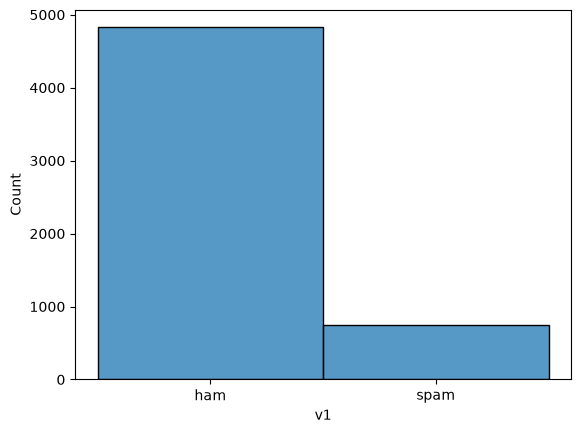

In [57]:
print(df.info(),"\n",df["v1"].value_counts())
print("\n\n",df["v2"][df["v1"] == "spam"].sample(10))
sns.histplot(data=df,x="v1")

In [58]:
print("Duplicated : ",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("\nDuplicated : ",df.duplicated().sum())

Duplicated :  403

Duplicated :  0


In [59]:
rename_mapping = {
    "v1" : "label",
    "v2" : "text"
}
df.rename(columns = rename_mapping,inplace=True)
print(df.columns)
oe = OrdinalEncoder()
df["label"] = oe.fit_transform(df[["label"]])

Index(['label', 'text'], dtype='str')


# The dataset doesn't have any direct mathematical or even categorical proportions. So we do :
# Text Procceing

In [60]:
X = df["text"]
y = df["label"]
X_train , X_test, y_train , y_test = train_test_split(X,y,random_state=25,stratify=y)

In [61]:
logisticRegression = Pipeline([
    ("preproccesor",TfidfVectorizer()),
    ("model",LogisticRegression())
])
logisticRegression.fit(X_train,y_train)
y_pred = logisticRegression.predict(X_test)
print("Testing logisticRegression ...\n\n","Accuracy: ",cross_val_score(logisticRegression,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))


Testing logisticRegression ...

 Accuracy:  0.9187991978689652 

Confusion Matrix : 
 [[1129    1]
 [  40  123]] 

Precision : 0.9919354838709677 
recall :  0.754601226993865 
 F1 Score :  0.8571428571428571


In [62]:
multinomialNB = Pipeline([
    ("preproccesor",TfidfVectorizer()),
    ("model", MultinomialNB())
])
multinomialNB.fit(X_train,y_train)
y_pred = multinomialNB.predict(X_test)
print("Testing MultinomialNB ...\n\n","Accuracy: ",cross_val_score(multinomialNB,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Testing MultinomialNB ...

 Accuracy:  0.9095088443925652 

Confusion Matrix : 
 [[1130    0]
 [  70   93]] 

Precision : 1.0 
recall :  0.5705521472392638 
 F1 Score :  0.7265625


In [63]:
randomForestClassifier = Pipeline([
    ("preproccesor",TfidfVectorizer()),
    ("model", RandomForestClassifier())
])
randomForestClassifier.fit(X_train,y_train)
y_pred = randomForestClassifier.predict(X_test)
print("Testing RandomForestClassifier ...\n\n","Accuracy: ",cross_val_score(randomForestClassifier,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Testing RandomForestClassifier ...

 Accuracy:  0.9419921582712281 

Confusion Matrix : 
 [[1130    0]
 [  35  128]] 

Precision : 1.0 
recall :  0.7852760736196319 
 F1 Score :  0.8797250859106529


# optimizating RandomForestClassifier (RandomForestClassifier) by finding best training parameters

In [64]:
params = {
    "model__max_depth":[1,2,3,5,8,15,30],
    "model__min_samples_leaf":[1,2,5,10,15,28],
    "model__min_samples_split":[1,5,10,15,25,30]
}
print("Finding Best parameters for randomForestClassifier (RandomForestClassifier) ... \n\n")
gr = GridSearchCV(randomForestClassifier,param_grid=params,scoring="f1")
gr.fit(X_train,y_train)
print("Best Parameters : ",gr.best_params_,"\nBest f1 score : ",gr.best_score_)
randomForestClassifier = gr.best_estimator_
y_pred = randomForestClassifier.predict(X_test)
print("\n\nTesting the new version of RandomForestClassifier ...\n\n","Accuracy: ",cross_val_score(randomForestClassifier,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Finding Best parameters for randomForestClassifier (RandomForestClassifier) ... 




Best Parameters :  {'model__max_depth': 30, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5} 
Best f1 score :  0.8419472342500697


Testing the new version of RandomForestClassifier ...

 Accuracy:  0.9458591481847296 

Confusion Matrix : 
 [[1130    0]
 [  51  112]] 

Precision : 1.0 
recall :  0.6871165644171779 
 F1 Score :  0.8145454545454546


In [65]:
params = {
    "model__max_depth":[100,105,110],
    "model__min_samples_leaf":[1],
    "model__min_samples_split":[26,27,28]
}
gr2 = GridSearchCV(randomForestClassifier,param_grid=params,scoring="f1")
gr2.fit(X_train,y_train)
print("Best Parameters : ",gr2.best_params_,"\nBest f1 score : ",gr2.best_score_)
randomForestClassifier = gr.best_estimator_
y_pred = randomForestClassifier.predict(X_test)
print("\n\nTesting the new version of RandomForestClassifier ...\n\n","Accuracy: ",cross_val_score(randomForestClassifier,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Best Parameters :  {'model__max_depth': 105, 'model__min_samples_leaf': 1, 'model__min_samples_split': 26} 
Best f1 score :  0.8891159805009459


Testing the new version of RandomForestClassifier ...

 Accuracy:  0.9419921582712281 

Confusion Matrix : 
 [[1130    0]
 [  51  112]] 

Precision : 1.0 
recall :  0.6871165644171779 
 F1 Score :  0.8145454545454546


In [66]:
randomForestClassifier = gr2.best_estimator_
y_pred = randomForestClassifier.predict(X_test)
print("\n\nTesting the new version of RandomForestClassifier ...\n\n","Accuracy: ",cross_val_score(randomForestClassifier,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))



Testing the new version of RandomForestClassifier ...

 Accuracy:  0.9466283559306815 

Confusion Matrix : 
 [[1128    2]
 [  33  130]] 

Precision : 0.9848484848484849 
recall :  0.7975460122699386 
 F1 Score :  0.8813559322033898


# optimizating logisticRegression (logisticRegression) by finding best training parameters

In [67]:

params = {
    "model__C": [0.1, 1, 10,50],
    "model__class_weight": [None, "balanced"],
    "model__penalty": ["l2"]
}
print("Finding Best parameters for logisticRegression (logisticRegression) ... \n\n")
gr = GridSearchCV(logisticRegression,param_grid=params,scoring="accuracy")
gr.fit(X_train,y_train)
print("Best Parameters : ",gr.best_params_,"\nBest Accuracy score : ",gr.best_score_)
logisticRegression = gr.best_estimator_
y_pred = logisticRegression.predict(X_test)
print("\n\nTesting the new version of logisticRegression ...\n\n","Accuracy: ",cross_val_score(logisticRegression,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Finding Best parameters for logisticRegression (logisticRegression) ... 


Best Parameters :  {'model__C': 50, 'model__class_weight': 'balanced', 'model__penalty': 'l2'} 
Best Accuracy score :  0.9868427003658132


Testing the new version of logisticRegression ...

 Accuracy:  0.97370327137769 

Confusion Matrix : 
 [[1123    7]
 [  18  145]] 

Precision : 0.9539473684210527 
recall :  0.8895705521472392 
 F1 Score :  0.9206349206349206


In [69]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","MultinomialNB","Random Forest"],
    "CV Accuracy": [0.97370327137769 ,0.9095088443925652 ,0.9419921582712281],
    "Precision": [0.9539473684210527,1.0,1.0],
    "Recall": [0.8895705521472392 ,0.5705521472392638,0.6871165644171779]
})
results = results.sort_values(by="CV Accuracy",ascending=False)
results

,Model,CV Accuracy,Precision,Recall
0,Logistic Regression,0.973703,0.953947,0.889571
2,Random Forest,0.941992,1.000000,0.687117
1,MultinomialNB,0.909509,1.000000,0.570552
